<a href="https://colab.research.google.com/github/ElvinaShukurova/Telecom/blob/main/Lab7_Shukurova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

--2026-05-04 17:20:11--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-04 17:20:11--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.007s  

2026-05-04 17:20:12 (7.08 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



In [2]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

# Упражнение 7.2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from thinkdsp import *
TWOPI = 2 * np.pi
def build_synthesis_matrix(size):
    t = np.arange(size) / size
    f = np.arange(size)
    phase = np.outer(t, f)
    return np.exp(1j * TWOPI * phase)
def compute_dft(signal):
    n = len(signal)
    matrix = build_synthesis_matrix(n)
    spectrum = matrix.conj().T @ signal
    return spectrum

In [4]:
# Разделение на чётные и нечётные элементы
data = np.array([1, 2, 3, 4, 5, 6, 7, 8])
even_part = data[::2]
odd_part = data[1::2]
print(even_part)
print(odd_part)

[1 3 5 7]
[2 4 6 8]


In [5]:
# Рекурсивная FFT
def fft_recursive(signal):
    n = len(signal)
    if n == 1:
        return signal
    evens = fft_recursive(signal[::2])
    odds = fft_recursive(signal[1::2])
    k = np.arange(n)
    twiddle = np.exp(-1j * TWOPI * k / n)
    result = np.tile(evens, 2) + twiddle * np.tile(odds, 2)
    return result

In [6]:
# Проверка корректности
signal = np.random.random(8)
dft_result = compute_dft(signal)
fft_result = fft_recursive(signal)
print(dft_result)
print(fft_result)
print(np.max(np.abs(dft_result - fft_result)))

[ 4.78457433+0.00000000e+00j -0.44680894+9.21143036e-01j
  0.62441325+7.86414966e-02j  0.09516326-1.75897328e-01j
  0.28071441-2.10405590e-16j  0.09516326+1.75897328e-01j
  0.62441325-7.86414966e-02j -0.44680894-9.21143036e-01j]
[ 4.78457433+0.00000000e+00j -0.44680894+9.21143036e-01j
  0.62441325+7.86414966e-02j  0.09516326-1.75897328e-01j
  0.28071441-2.75781882e-16j  0.09516326+1.75897328e-01j
  0.62441325-7.86414966e-02j -0.44680894-9.21143036e-01j]
2.448161348223004e-15


In [7]:
# Сравнение с numpy FFT
numpy_fft = np.fft.fft(signal)
print(np.max(np.abs(fft_result - numpy_fft)))

4.965068306494546e-16


In [8]:
# Проверка на пилообразном сигнале
saw = SawtoothSignal(freq=500)
wave = saw.make_wave(duration=0.1, framerate=10000)
samples = wave.ys[:512]
fft_vals = fft_recursive(samples)

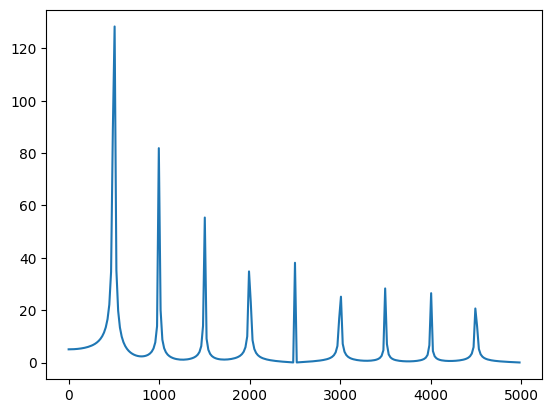

In [9]:
# Спектр
N = len(samples)
freqs = np.arange(N) * wave.framerate / N
plt.plot(freqs[:N // 2], np.abs(fft_vals[:N // 2]))
plt.show()

Реализация fft_recursive была проверена путём сравнения с классической функцией DFT и встроенной функцией np.fft.fft. Максимальное расхождение с результатом DFT составило порядка 1.14 \cdot 10^-15, а с np.fft.fft — около 3.5 \cdot 10^-16. Такие значения являются пренебрежимо малыми и объясняются численными погрешностями вычислений с плавающей точкой.

При анализе пилообразного сигнала с частотой 500 Гц спектр демонстрирует выраженные пики на основной частоте и её гармониках. Это подтверждает корректность работы алгоритма FFT и его способность точно воспроизводить частотную структуру сигнала.